In [1]:
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import pandas as pd
import os
from pathlib import Path
from scipy.interpolate import interp1d as interp1d
import scipy.integrate as intg
import scipy

In [ ]:
table_b = open('IDM_continuous','r')#IDM_CTA_10.PhaseSpace_all_b m
Columns_b = table_b.readline().split()

data_b = np.genfromtxt('IDM_continuous',dtype=float, comments='#')[1:,:]
table_b.close()

In [3]:
values_b = pd.DataFrame(data_b,columns=Columns_b)
values_b

,Lambda345,MDM,d0,d+,Omega
0,0.023014,2750.20,4.49400,2.62630,0.533130
1,0.900500,319.14,1.28620,5.53100,0.001209
2,0.053439,28029.00,0.71351,0.50053,19.757000
3,0.950600,13207.00,0.50831,1.31630,1.038000
4,0.498650,1717.30,1.93740,1.77550,0.089986
...,...,...,...,...,...
249996,0.632970,1155.10,1.45790,9.63710,0.017873
249997,0.016320,2138.20,7.01890,0.53678,0.285480
249998,0.176430,970.77,1.58640,0.75822,0.147930
249999,0.020617,10196.00,4.07220,3.68580,0.605860


In [4]:
lamb_b = sorted(list(set(np.array(values_b['Lambda345']))))
M_b = sorted(list(set(np.array(values_b['MDM']))))
print(len(lamb_b),len(M_b))

136271 119413


In [5]:
dMi = M_b[1] - M_b[0]
dMf = M_b[-1] - M_b[-2]
dlambi = lamb_b[1] - lamb_b[0]
dlambf = lamb_b[-1] - lamb_b[-2]
print(dMi,dMf)
print(dlambi,dlambf)
print(lamb_b[0],lamb_b[-1])

0.009999999999990905 1.0
9.999999999992654e-07 0.000300000000000189
0.01 6.2


In [6]:
table_xenon = open('CDD_all_XENONnT','r')#IDM_CTA_10.PhaseSpace_all_b m
Columns_xenon = table_xenon.readline().split()

data_xenon = np.genfromtxt('CDD_all_XENONnT',dtype=float, comments='#')[1:,:]
table_xenon.close()
values_xenon = pd.DataFrame(data_xenon,columns=Columns_xenon)

In [7]:
values_xenon

,Lambda345,MDM
0,0.021566,300.00
1,0.022213,306.00
2,0.022222,312.12
3,0.022890,318.36
4,0.023576,324.73
...,...,...
228,NaN,27413.00
229,NaN,27962.00
230,NaN,28521.00
231,NaN,29091.00


In [8]:
condition_constraint = (values_xenon['Lambda345']*0 == 0 )
DD_limit = interp1d(values_xenon['MDM'][condition_constraint],values_xenon['Lambda345'][condition_constraint],bounds_error=False,fill_value=(values_xenon['Lambda345'][0],max(values_xenon['Lambda345'])))
M_xenon = max(values_xenon['MDM'][condition_constraint])


In [9]:
M_xenon = max(values_xenon['MDM'][condition_constraint])

In [20]:
table_lz = open('CDD_all_LZ','r')#IDM_CTA_10.PhaseSpace_all_b m
Columns_lz = table_lz.readline().split()

data_lz = np.genfromtxt('CDD_all_LZ',dtype=float, comments='#')[1:,:]
table_lz.close()
values_lz = pd.DataFrame(data_lz,columns=Columns_xenon)
values_lz


,Lambda345,MDM
0,0.015126,300.00
1,0.015133,306.00
2,0.015586,312.12
3,0.016054,318.36
4,0.016536,324.73
...,...,...
228,NaN,27413.00
229,NaN,27962.00
230,NaN,28521.00
231,NaN,29091.00


In [29]:
condition_constraint = (values_lz['Lambda345']*0 == 0 )
DD_limit = interp1d(values_lz['MDM'][condition_constraint],values_lz['Lambda345'][condition_constraint],bounds_error=False,fill_value=(values_lz['Lambda345'][0],max(values_lz['Lambda345'])))
M_lz = max(values_xenon['MDM'][condition_constraint])


# Theoretical Constraints

In [30]:
vev = 246
l1 = 0.129

def plus(m,dplus):
    plus = dplus*(2.*m + dplus)/(vev**2.)
    return plus

def zero(m,dzero):
    zero = dzero*(2.*m + dzero)/(vev**2.)
    return zero

##############

def c1(l,m,dplus,dzero):
    c1 = - 2.*l + 8.*np.pi - zero(m,dzero) 
    return np.array(c1)

def c2(l,m,dplus,dzero):
    c2 = 8.*np.pi + zero(m,dzero) - 4.*plus(m,dplus) -2.*l
    return np.array(c2)

def c3(l,m,dplus,dzero):
    c3 = 8.*np.pi*np.sqrt(1-0.75*l1/np.pi) - zero(m,dzero) - 2.*plus(m,dplus)  - 4.*l
    return np.array(c3)

def c6(l,m,dplus,dzero):
    c6 = 8.*np.pi - zero(m,dzero) - 2.*plus(m,dplus) - 2.*l
    return np.array(c6)


def c10(l,m,dplus,dzero):
    c10 = 8.*np.pi - 5.*zero(m,dzero) + 2.*plus(m,dplus)   - 2.*l
    return np.array(c10)


In [31]:
T_condition = (      
                (c1(values_b['Lambda345'],values_b['MDM'],values_b['d+'],values_b['d0'])   > 0) &
                (c2(values_b['Lambda345'],values_b['MDM'],values_b['d+'],values_b['d0'])   > 0) &
                (c3(values_b['Lambda345'],values_b['MDM'],values_b['d+'],values_b['d0'])   > 0) &
                (c6(values_b['Lambda345'],values_b['MDM'],values_b['d+'],values_b['d0'])   > 0) &
                (c10(values_b['Lambda345'],values_b['MDM'],values_b['d+'],values_b['d0'])   > 0) &
                ((values_b['MDM']**2. - values_b['Lambda345']*(vev**2.) ) >0 )

)

In [32]:
values_t = values_b[T_condition]

In [33]:
Omega_ob = 0.1184
tolomega = 1e-2
CA = values_t[((values_t['Omega']/Omega_ob - 1 < tolomega) & (values_t['Omega']/Omega_ob - 1 > -tolomega))]
UA = values_t[((values_t['Omega'] <= Omega_ob) & (values_t['Omega'] <= Omega_ob))]

In [34]:
ncv = np.shape(UA)[0]
ncv

105373

In [35]:
DD_condition = ( values_t['Lambda345'] < DD_limit(values_t['MDM']) )
DD_UA_condition = ( UA['Lambda345'] < DD_limit(UA['MDM']) )

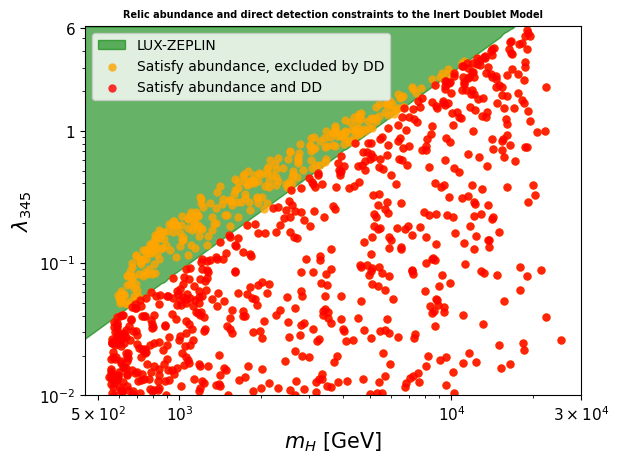

In [37]:
plt.xscale('log')
plt.yscale('log')

#plt.scatter(values_b['MDM'],values_b['Lambda345'],color='green',marker='o',linewidths=0.01,label="Excluded by DD and RA")
#plt.scatter(values_b['MDM'][DD_condition],values_b['Lambda345'][DD_condition],color='black',marker='o',linewidths=0.01,label="Excluded just by RA")
plt.fill_between(np.array(M_b),
                 DD_limit(np.array(M_b)),
                 max(values_lz['Lambda345']),#max(values_xenon['Lambda345'])
                 where= (np.array(M_b)<M_lz),
                 color='green',
                 label='LUX-ZEPLIN',
                alpha = 0.6)
plt.scatter(CA['MDM'],CA['Lambda345'],color='orange',marker='o',linewidths=0.01,label="Satisfy abundance, excluded by DD",alpha=0.8)
plt.scatter(CA['MDM'][DD_condition],CA['Lambda345'][DD_condition],color='red',marker='o',linewidths=0.01,label="Satisfy abundance and DD",alpha=0.8)

plt.xlim(450,3e4)
plt.ylim(lamb_b[0],lamb_b[-1])

plt.xticks([5e2,1e3,1e4,3e4],[r'$ 5 \times 10^2 $',r'$ 10^3 $',r'$ 10^4 $',r'$ 3 \times 10^4 $'],fontsize=11)
plt.yticks([1e-2,1e-1,1e0,6],[r'$ 10^{-2} $',r'$ 10^{-1} $',r'$ 1 $',r'$ 6 $'],fontsize=11)

plt.ylabel(r"$\lambda_{345}$",fontsize=15)
plt.xlabel(r"$m_H$ [GeV]",fontsize=15)
plt.title('Relic abundance and direct detection constraints to the Inert Doublet Model',fontweight='bold',fontsize=7)

plt.legend()
plt.savefig("IDM_continuous_scan_CA_LZ.pdf",bbox_inches='tight')



In [22]:
CA_DD = CA[DD_condition]
CA_DD

/tmp/ipykernel_17613/3522304185.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  CA_DD = CA[DD_condition]


,Lambda345,MDM,d0,d+,Omega
249,0.113090,3275.60,5.70930,8.67800,0.11804
472,0.010464,10235.00,7.48360,9.52000,0.11922
491,0.030148,581.32,2.32230,0.59034,0.11855
874,0.137870,1257.90,0.57114,6.19470,0.11768
991,0.046734,9352.60,8.95220,8.87390,0.11754
...,...,...,...,...,...
248009,2.228700,8686.80,1.27070,2.57990,0.11862
248186,0.185320,6330.50,1.14810,9.28620,0.11821
248305,0.029468,1561.90,3.72700,8.57810,0.11910
249048,0.616240,3470.60,7.47020,1.15640,0.11807


In [96]:
table = open('CA_continuous','w')
table.write("Lambda345 MDM d0 d+ Omega\n")

for line in CA_DD.T:
    table.write(str(CA_DD['Lambda345'][line])+' '+str(CA_DD['MDM'][line])+' '+str(CA_DD['d0'][line])+' '+str(CA_DD['d+'][line])+' '+str(CA_DD['Omega'][line])+'\n')


table.close()

# Upper abundance limit

<Figure size 640x480 with 0 Axes>

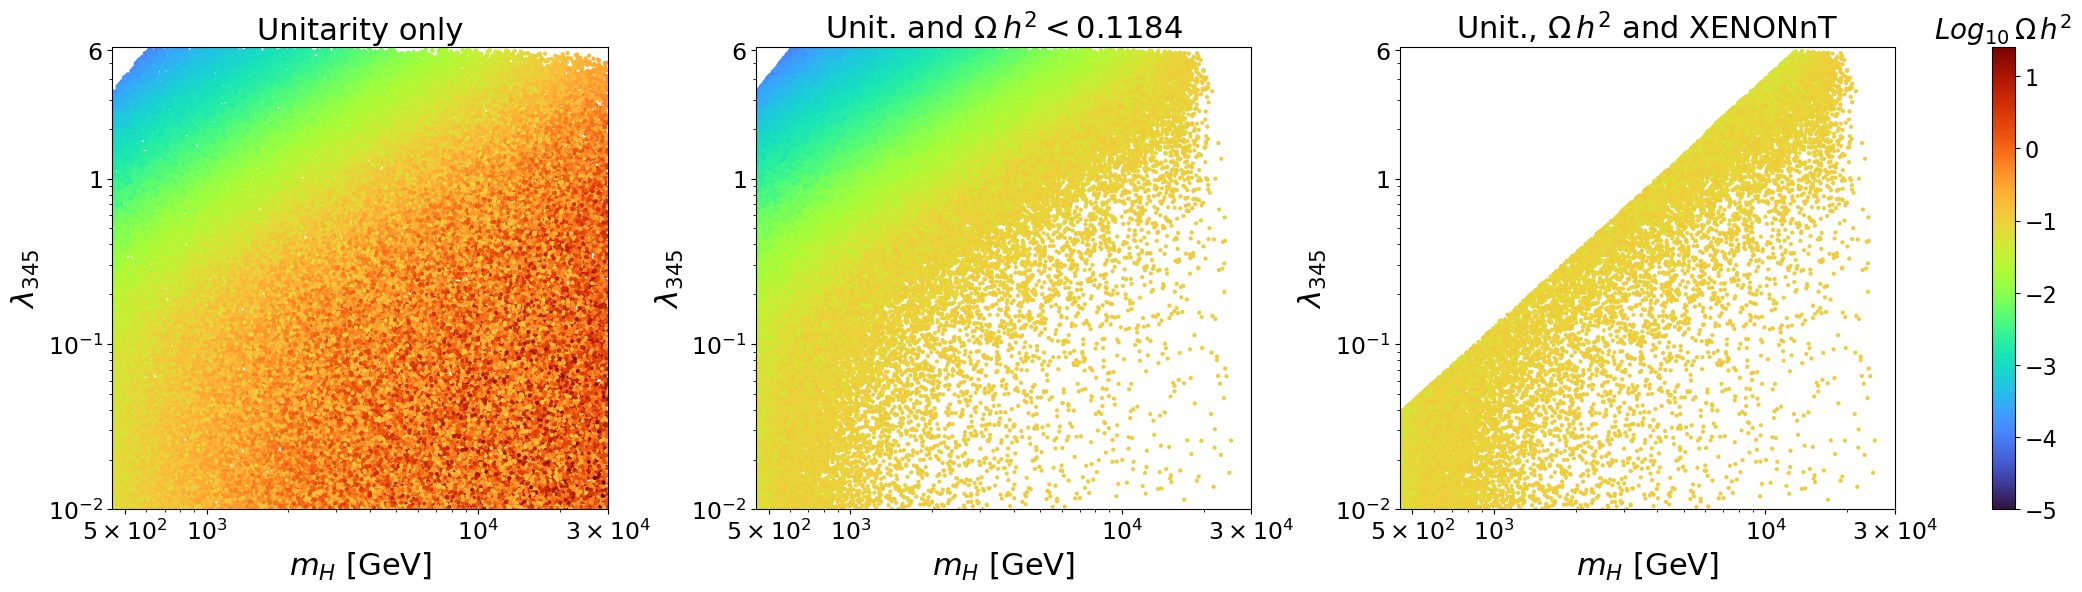

In [24]:
plt.figure(10)
fig, axs = plt.subplots(1, 3,figsize=(25,6))
fig.subplots_adjust(hspace=0.2,wspace=0.3)

im0 = axs[0].scatter(values_t['MDM'][0:ncv+1:1],
            values_t['Lambda345'][0:ncv+1:1],
            c = np.log10(values_t['Omega'])[0:ncv+1:1],
            marker='.',
            cmap='turbo',vmin=-5,vmax=1.4,
            linewidths=0.01)

       

###

im1 = axs[1].scatter(UA['MDM'][0:ncv+1:1],
            UA['Lambda345'][0:ncv+1:1],
            c = np.log10(UA['Omega'])[0:ncv+1:1],
            marker='.',
            cmap='turbo',vmin=-5,vmax=1.4,
            linewidths=0.01)

    
###

im2 = axs[2].scatter(UA[DD_UA_condition]['MDM'][0:ncv+1:1],
            UA[DD_UA_condition]['Lambda345'][0:ncv+1:1],
            c = np.log10(UA[DD_UA_condition]['Omega'])[0:ncv+1:1],
            marker='.',
            cmap='turbo',vmin=-5,vmax=1.4,
            linewidths=0.01)



####################################3
axs[0].set_ylabel(r"$\lambda_{345}$",fontsize=22)
axs[0].set_xlabel(r"$m_H$ [GeV]",fontsize=22)

axs[1].set_ylabel(r"$\lambda_{345}$",fontsize=22)
axs[1].set_xlabel(r"$m_H$ [GeV]",fontsize=22)

axs[2].set_ylabel(r"$\lambda_{345}$",fontsize=22)
axs[2].set_xlabel(r"$m_H$ [GeV]",fontsize=22)


axs[0].set_xlim(4.5e2,3e4)
axs[1].set_xlim(4.5e2,3e4)
axs[2].set_xlim(4.5e2,3e4)

axs[0].set_ylim(lamb_b[0],lamb_b[-1])
axs[1].set_ylim(lamb_b[0],lamb_b[-1])
axs[2].set_ylim(lamb_b[0],lamb_b[-1])

mass_values = [5e2,1e3,1e4,3e4]
mass_names = [r'$5\times 10^2$',r'$10^3$',r'$10^4$',r'$3\times 10^4$']

axs[0].set_xscale('log')
axs[1].set_xscale('log')
axs[2].set_xscale('log')

axs[0].set_yscale('log')
axs[1].set_yscale('log')
axs[2].set_yscale('log')

l_values = [1e-2,1e-1,1,6]
l_names = [r'$10^{-2}$',r'$10^{-1}$',r'$1$',r'$ 6$']

axs[0].set_xticks(ticks=mass_values, labels=mass_names,fontsize=17)
axs[1].set_xticks(ticks=mass_values, labels=mass_names,fontsize=17)
axs[2].set_xticks(ticks=mass_values, labels=mass_names,fontsize=17)

axs[0].set_yticks(ticks=l_values, labels=l_names,fontsize=17)
axs[1].set_yticks(ticks=l_values, labels=l_names,fontsize=17)
axs[2].set_yticks(ticks=l_values, labels=l_names,fontsize=17)
#axs[0].set_xlim(M_b[0],M_b[-1])
#axs[1].set_xlim(M_b[0],M_b[-1])
#axs[2].set_xlim(M_b[0],M_b[-1])

axs[0].set_title('Unitarity only',fontsize=22)
axs[1].set_title(r'Unit. and $ \Omega \, h^2 < 0.1184 $',fontsize=22)
axs[2].set_title('Unit., $ \Omega \, h^2 $ and XENONnT',fontsize=22)

cbar = fig.colorbar(im0, ax=axs.ravel().tolist(),aspect=20,orientation="vertical",fraction=0.03)
cbar.ax.tick_params(labelsize=16)
cbar.ax.set_title(r'$Log_{10} \, \Omega \, h^2$',fontsize=20)

plt.savefig("IDM_continuous_scan_UA2.pdf",bbox_inches='tight')

In [41]:
np.log10(np.max(values_t['Omega']))

1.4032406650844753

In [22]:
np.min(values_t['d0'])

0.5